---
title: "TensorFlow GPU example"
subtitle: "Device checks, benchmarks (GPU vs CPU), and CNN training."
author: "Author: Ignacio Masari (EODC)"
tags: [TensorFlow, CUDA, Deep Learning, GPU]
thumbnail: ../img/DE_logo.jpg
license: MIT
copyright: "© 2026 EODC GmbH."
---

# TensorFlow GPU Example

Run TensorFlow on GPU for dense linear algebra and small neural-network training workloads.

| | |
|---|---|
| **Data** | Synthetic matrices, Fashion-MNIST, two-moons samples |
| **Task** | GPU check, matmul benchmark, CNN training |
| **Framework** | TensorFlow + Keras |
| **Expected runtime** | ~3 min on CPU &nbsp;|&nbsp; <1 min on GPU |

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3" 
import tensorflow as tf

print(f"TensorFlow : {tf.__version__}")
gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs found : {len(gpus)}")
for g in gpus:
    print(" ", g)
build = tf.sysconfig.get_build_info()
print(f"CUDA       : {build.get('cuda_version', 'n/a')}")
print(f"cuDNN      : {build.get('cudnn_version', 'n/a')}")

TensorFlow : 2.21.0
GPUs found : 1
  PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
CUDA       : 12.5.1
cuDNN      : 9


## 1. CPU vs GPU matrix multiply

In [2]:
import time

def bench_tf_matmul(device_str, N, repeats=5, warmup=2):
    with tf.device(device_str):
        a = tf.random.normal([N, N])
        b = tf.random.normal([N, N])
        for _ in range(warmup):
            _ = tf.matmul(a, b).numpy()
        ts = []
        for _ in range(repeats):
            t0 = time.perf_counter()
            _ = tf.matmul(a, b).numpy()
            ts.append(time.perf_counter() - t0)
        return min(ts)

N = 4096
t_cpu = bench_tf_matmul("/CPU:0", N)
print(f"CPU matmul {N}x{N}: {t_cpu*1000:8.1f} ms")
if gpus:
    t_gpu = bench_tf_matmul("/GPU:0", N)
    print(f"GPU matmul {N}x{N}: {t_gpu*1000:8.1f} ms   (speedup: {t_cpu/t_gpu:5.1f}x)")

CPU matmul 4096x4096:    380.1 ms
GPU matmul 4096x4096:     61.3 ms   (speedup:   6.2x)


## 2. Scaling plot — CPU vs GPU matmul as N grows

N=  256  CPU=     0.3 ms  GPU=    0.25 ms
N=  512  CPU=     1.0 ms  GPU=    0.42 ms
N= 1024  CPU=     6.4 ms  GPU=    0.99 ms
N= 2048  CPU=    46.3 ms  GPU=    3.27 ms


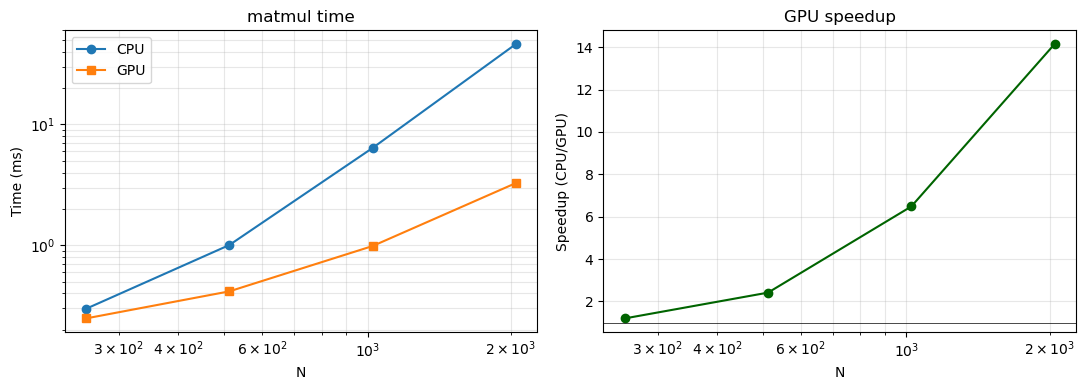

In [3]:
import matplotlib.pyplot as plt
import numpy as np

sizes = [256, 512, 1024, 2048]
cpu_t = [bench_tf_matmul("/CPU:0", n) * 1000 for n in sizes]
gpu_t = [bench_tf_matmul("/GPU:0", n) * 1000 if gpus else float("nan") for n in sizes]
for n, c, g in zip(sizes, cpu_t, gpu_t):
    print(f"N={n:5d}  CPU={c:8.1f} ms  GPU={g:8.2f} ms")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].loglog(sizes, cpu_t, "o-", label="CPU")
axes[0].loglog(sizes, gpu_t, "s-", label="GPU")
axes[0].set_xlabel("N"); axes[0].set_ylabel("Time (ms)")
axes[0].set_title("matmul time"); axes[0].legend(); axes[0].grid(True, which="both", alpha=0.3)
speedup = [c/g for c, g in zip(cpu_t, gpu_t)]
axes[1].semilogx(sizes, speedup, "o-", color="darkgreen")
axes[1].axhline(1, color="black", lw=0.5)
axes[1].set_xlabel("N"); axes[1].set_ylabel("Speedup (CPU/GPU)")
axes[1].set_title("GPU speedup"); axes[1].grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

## 3. CPU vs GPU CNN training — Fashion-MNIST

We train the same small CNN on Fashion-MNIST for a few epochs, once on each device.

In [4]:
(x_tr, y_tr), (x_te, y_te) = tf.keras.datasets.fashion_mnist.load_data()
x_tr = (x_tr.astype("float32") / 255.0)[..., None]
x_te = (x_te.astype("float32") / 255.0)[..., None]
print("Train:", x_tr.shape, "  Test:", x_te.shape)

def make_cnn():
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(28, 28, 1)),
        tf.keras.layers.Conv2D(32, 3, activation="relu"),
        tf.keras.layers.MaxPool2D(),
        tf.keras.layers.Conv2D(64, 3, activation="relu"),
        tf.keras.layers.MaxPool2D(),
        tf.keras.layers.Conv2D(128, 3, activation="relu"),
        tf.keras.layers.GlobalAvgPool2D(),
        tf.keras.layers.Dense(10),
    ])

def train_on(device_str, epochs=3):
    with tf.device(device_str):
        m = make_cnn()
        m.compile(optimizer="adam",
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=["accuracy"])
        # warm-up batch (avoids cuDNN kernel-search latency in the timing)
        m.train_on_batch(x_tr[:64], y_tr[:64])
        t0 = time.perf_counter()
        m.fit(x_tr, y_tr, batch_size=256, epochs=epochs, verbose=0)
        t = time.perf_counter() - t0
        acc = m.evaluate(x_te, y_te, verbose=0)[1]
    return t, acc

t_cpu, a_cpu = train_on("/CPU:0", epochs=2)
print(f"CPU  : {t_cpu:6.1f}s  acc={a_cpu:.4f}")
if gpus:
    t_gpu, a_gpu = train_on("/GPU:0", epochs=2)
    print(f"GPU  : {t_gpu:6.1f}s  acc={a_gpu:.4f}   (speedup: {t_cpu/t_gpu:.1f}x)")

Train: (60000, 28, 28, 1)   Test: (10000, 28, 28, 1)
CPU  :   54.6s  acc=0.8006
GPU  :   14.4s  acc=0.7938   (speedup: 3.8x)


## 4. Synthetic two-moons — dense net + decision boundary

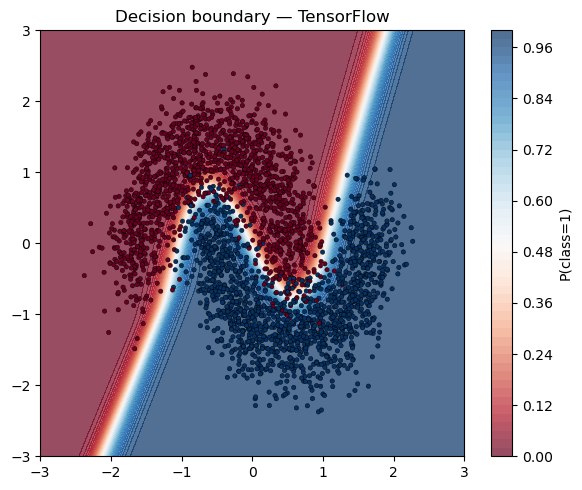

In [5]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

X, y = make_moons(n_samples=3000, noise=0.2, random_state=42)
X = StandardScaler().fit_transform(X).astype("float32")
y = y.astype("float32")

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
history = model.fit(X, y, epochs=50, batch_size=256, validation_split=0.2, verbose=0)

xx, yy = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))
grid = np.c_[xx.ravel(), yy.ravel()].astype("float32")
preds = model.predict(grid, verbose=0).reshape(xx.shape)
plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, preds, levels=50, cmap="RdBu", alpha=0.7)
plt.colorbar(label="P(class=1)")
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="RdBu", s=10, edgecolors="k", linewidths=0.3)
plt.title("Decision boundary — TensorFlow"); plt.tight_layout(); plt.show()